# Support Triage Agent — Golden-Dataset Evaluation Report

Reads `evaluation/eval_report.json` -- the real output of
`python evaluation/run_eval.py` scoring every ticket's routing decision
against `evaluation/golden_dataset.json`'s expected route, run against the
live Groq API.

Three metrics, each with a target the harness pass/fails against:

| Metric | Target | What it measures |
|---|---|---|
| Route accuracy | ≥ 90% | Does `route_decision` match the golden label? |
| Citation presence | 100% of `AUTO_RESOLVE` drafts | Every auto-resolved reply cites a policy source |
| Fabricated citation rate | 0% | No cited source is absent from what was actually retrieved |

In [1]:
import sys, json
from pathlib import Path
from datetime import datetime, timezone

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.config.settings import get_settings

settings = get_settings()
report_path = REPO_ROOT / "evaluation" / "eval_report.json"
report = json.loads(report_path.read_text(encoding="utf-8"))
summary = report["summary"]

generated_at = datetime.fromtimestamp(report_path.stat().st_mtime, tz=timezone.utc)
print(f"evaluation/eval_report.json generated {generated_at.isoformat()}")
print(json.dumps(summary, indent=2))

evaluation/eval_report.json generated 2026-08-14T13:48:52.468937+00:00
{
  "total_tickets": 22,
  "correct_routes": 22,
  "route_accuracy": 1.0,
  "route_accuracy_target": 0.9,
  "route_accuracy_pass": true,
  "auto_resolve_count": 6,
  "citation_presence_rate": 1.0,
  "citation_presence_target": 1.0,
  "citation_presence_pass": true,
  "fabricated_citation_rate": 0.0,
  "fabricated_citation_target": 0.0,
  "fabricated_citation_pass": true,
  "overall_pass": true
}


## Summary — pass/fail against target

In [2]:
import pandas as pd

summary_rows = [
    {
        "metric": "Route accuracy",
        "value": f"{summary['route_accuracy']:.1%}",
        "target": f">= {summary['route_accuracy_target']:.0%}",
        "result": "PASS" if summary["route_accuracy_pass"] else "FAIL",
    },
    {
        "metric": "Citation presence (of AUTO_RESOLVE drafts)",
        "value": f"{summary['citation_presence_rate']:.1%}",
        "target": f">= {summary['citation_presence_target']:.0%}",
        "result": "PASS" if summary["citation_presence_pass"] else "FAIL",
    },
    {
        "metric": "Fabricated citation rate",
        "value": f"{summary['fabricated_citation_rate']:.1%}",
        "target": f"<= {summary['fabricated_citation_target']:.0%}",
        "result": "PASS" if summary["fabricated_citation_pass"] else "FAIL",
    },
]
metrics_df = pd.DataFrame(summary_rows)
print(f"OVERALL: {'PASS' if summary['overall_pass'] else 'FAIL'}  "
      f"({summary['correct_routes']}/{summary['total_tickets']} tickets routed correctly)")
metrics_df

OVERALL: PASS  (22/22 tickets routed correctly)


,metric,value,target,result
0,Route accuracy,100.0%,>= 90%,PASS
1,Citation presence (of AUTO_RESOLVE drafts),100.0%,>= 100%,PASS
2,Fabricated citation rate,0.0%,<= 0%,PASS


## Per-ticket results

In [3]:
tickets_df = pd.DataFrame(report["tickets"])
tickets_df["result"] = tickets_df["route_correct"].map({True: "PASS", False: "FAIL"})
tickets_df[["ticket_id", "expected_route", "actual_route", "result", "route_reason", "groundedness_score", "has_citation"]]

,ticket_id,expected_route,actual_route,result,route_reason,groundedness_score,has_citation
0,TCK-1001,AUTO_RESOLVE,AUTO_RESOLVE,PASS,policy_grounded_response,0.556774,True
1,TCK-1002,ESCALATE,ESCALATE,PASS,repeat_refund_request_within_window,0.604440,True
2,TCK-1003,ESCALATE,ESCALATE,PASS,refund_outside_window,0.584357,True
3,TCK-1004,AUTO_RESOLVE,AUTO_RESOLVE,PASS,policy_grounded_response,0.606715,True
4,TCK-1005,ASK_INFO,ASK_INFO,PASS,missing_required_fields,0.473260,True
5,TCK-1006,ASK_INFO,ASK_INFO,PASS,missing_required_fields,0.598996,True
6,TCK-1007,ASK_INFO,ASK_INFO,PASS,classifier_requires_more_info,0.311817,True
7,TCK-1008,ESCALATE,ESCALATE,PASS,refund_outside_window,0.472145,True
8,TCK-1009,REFUSE,REFUSE,PASS,abusive_content_detected,0.215538,False
9,TCK-1010,REFUSE,REFUSE,PASS,refund_abuse_language_detected,0.632945,False


## Expected vs. actual route, by ticket count

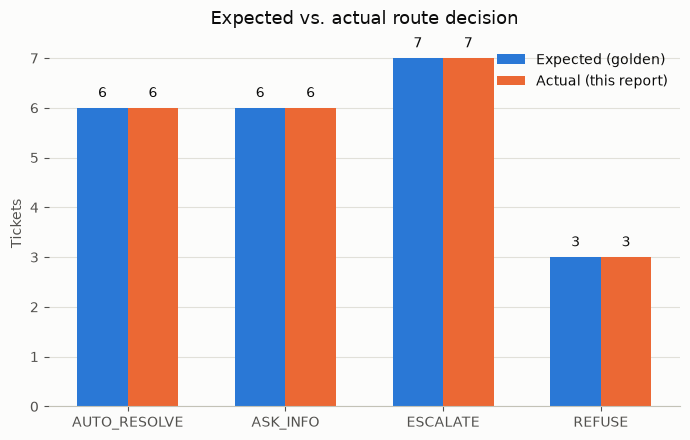

In [4]:
import matplotlib.pyplot as plt
import numpy as np

order = ["AUTO_RESOLVE", "ASK_INFO", "ESCALATE", "REFUSE"]
expected_counts = tickets_df["expected_route"].value_counts().reindex(order, fill_value=0)
actual_counts = tickets_df["actual_route"].value_counts().reindex(order, fill_value=0)

x = np.arange(len(order))
width = 0.32

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
b1 = ax.bar(x - width / 2, expected_counts.values, width, label="Expected (golden)", color="#2a78d6")
b2 = ax.bar(x + width / 2, actual_counts.values, width, label="Actual (this report)", color="#eb6834")
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.15, str(int(h)),
                ha="center", va="bottom", color="#0b0b0b", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Tickets", color="#52514e")
ax.set_title("Expected vs. actual route decision", color="#0b0b0b", fontsize=13, pad=12)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, labelcolor="#0b0b0b")
plt.tight_layout()
plt.show()

## Conclusion

In [5]:
if summary["overall_pass"]:
    print(f"OVERALL: PASS -- all three targets met on this {summary['total_tickets']}-ticket golden set.")
else:
    print("OVERALL: FAIL -- see per-ticket table above for which rows missed target.")

OVERALL: PASS -- all three targets met on this 22-ticket golden set.
